In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [4]:
df.columns.to_list()

['PassengerId',
 'HomePlanet',
 'CryoSleep',
 'Cabin',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'Name',
 'Transported']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [6]:
df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [7]:
df['HomePlanet'].unique()

<StringArray>
['Europa', 'Earth', 'Mars', nan]
Length: 4, dtype: str

In [8]:
home_planet_mode = df['HomePlanet'].mode()[0]
df['HomePlanet'] = df['HomePlanet'].fillna(home_planet_mode)
df.isna().sum()

PassengerId       0
HomePlanet        0
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [9]:
cryo_sleep_mode = df['CryoSleep'].mode()[0]
df['CryoSleep'] = df['CryoSleep'].fillna(cryo_sleep_mode)
df.isna().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [10]:
df['Cabin']

0          B/0/P
1          F/0/S
2          A/0/S
3          A/0/S
4          F/1/S
          ...   
8688      A/98/P
8689    G/1499/S
8690    G/1500/S
8691     E/608/S
8692     E/608/S
Name: Cabin, Length: 8693, dtype: str

In [11]:
df['Cabin_splitted'] = df['Cabin'].str.split('/')
df['deck'] = [x[0] if type(x) == list else None for x in df['Cabin_splitted']]
df['num'] = [int(x[1]) if type(x) == list else None for x in df['Cabin_splitted']]
df['side'] = [x[2] if type(x) == list else None for x in df['Cabin_splitted']]
df.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Cabin_splitted,deck,num,side
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,"[A, 98, P]",A,98.0,P
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,"[G, 1499, S]",G,1499.0,S
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,"[G, 1500, S]",G,1500.0,S
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,"[E, 608, S]",E,608.0,S
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True,"[E, 608, S]",E,608.0,S


In [12]:
df.isna().sum()

PassengerId         0
HomePlanet          0
CryoSleep           0
Cabin             199
Destination       182
Age               179
VIP               203
RoomService       181
FoodCourt         183
ShoppingMall      208
Spa               183
VRDeck            188
Name              200
Transported         0
Cabin_splitted    199
deck              199
num               199
side              199
dtype: int64

In [13]:
deck_mode = df['deck'].mode()[0]
num_median = df['num'].median()
side_mode = df['side'].mode()[0]
df['deck'] = df['deck'].fillna(deck_mode)
df['num'] = df['num'].fillna(num_median)
df['side'] = df['side'].fillna(side_mode)
df.isna().sum()

PassengerId         0
HomePlanet          0
CryoSleep           0
Cabin             199
Destination       182
Age               179
VIP               203
RoomService       181
FoodCourt         183
ShoppingMall      208
Spa               183
VRDeck            188
Name              200
Transported         0
Cabin_splitted    199
deck                0
num                 0
side                0
dtype: int64

In [14]:
df['Destination'].unique()

<StringArray>
['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e', nan]
Length: 4, dtype: str

In [15]:
dest_mode = df['Destination'].mode()[0]
age_median = df['Age'].median()
vip_mode = df['VIP'].mode()[0]
room_service_median = df['RoomService'].median()
food_court_median = df['FoodCourt'].median()
shopping_mall_median = df['ShoppingMall'].median()
spa_median = df['Spa'].median()
vrdeck_median = df['VRDeck'].median()

df['Destination'] = df['Destination'].fillna(dest_mode)
df['Age'] = df['Age'].fillna(age_median)
df['VIP'] = df['VIP'].fillna(vip_mode)
df['RoomService'] = df['RoomService'].fillna(room_service_median)
df['FoodCourt'] = df['FoodCourt'].fillna(food_court_median)
df['ShoppingMall'] = df['ShoppingMall'].fillna(shopping_mall_median)
df['Spa'] = df['Spa'].fillna(spa_median)
df['VRDeck'] = df['VRDeck'].fillna(vrdeck_median)

df.drop(['Cabin', 'Name', 'Cabin_splitted'], axis=1, inplace = True)

df.isna().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
deck            0
num             0
side            0
dtype: int64

In [16]:
df.to_csv('not normalized processed titanic.csv', index=False)

scaler = MinMaxScaler()
#df['Age'] = scaler.fit_transform(df[['Age']])
scaler = MinMaxScaler()
#df['num'] = scaler.fit_transform(df[['num']])

df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,num
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,28.790291,220.009318,448.434027,169.572300,304.588865,298.261820,596.398942
std,14.341404,660.519050,1595.790627,598.007164,1125.562559,1134.126417,506.637799
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,173.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,427.000000
75%,37.000000,41.000000,61.000000,22.000000,53.000000,40.000000,983.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000,1894.000000


In [17]:
df = pd.get_dummies(df, columns=['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'deck', 'side'], drop_first = True)
df.head()

,PassengerId,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,num,HomePlanet_Europa,...,Destination_TRAPPIST-1e,VIP_True,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,side_S
0,0001_01,39.0,0.0,0.0,0.0,0.0,0.0,False,0.0,True,...,True,False,True,False,False,False,False,False,False,False
1,0002_01,24.0,109.0,9.0,25.0,549.0,44.0,True,0.0,False,...,True,False,False,False,False,False,True,False,False,True
2,0003_01,58.0,43.0,3576.0,0.0,6715.0,49.0,False,0.0,True,...,True,True,False,False,False,False,False,False,False,True
3,0003_02,33.0,0.0,1283.0,371.0,3329.0,193.0,False,0.0,True,...,True,False,False,False,False,False,False,False,False,True
4,0004_01,16.0,303.0,70.0,151.0,565.0,2.0,True,1.0,False,...,True,False,False,False,False,False,True,False,False,True


<Axes: >

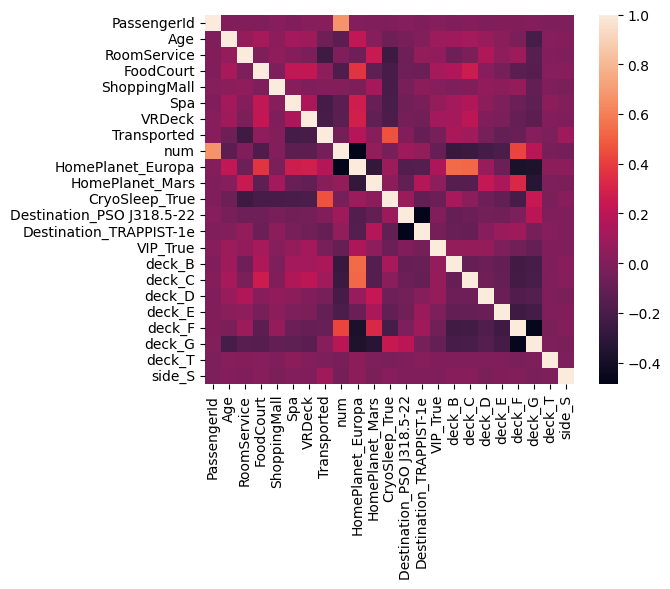

In [18]:
sns.heatmap(df.corr(), square=True)

In [19]:
df.to_csv('processed_titanic_without_normalization.csv', index=False)